In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Loading the data
df = pd.read_csv('PremierLeague.csv')


# Convert the 'Date' column to datetime format
# This is because we want to sort matches correctly in time

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values('Date').reset_index(drop=True)

/var/folders/db/bz186_t55wz58ywwqghvfvgr0000gp/T/ipykernel_2406/78016232.py:13: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')


In [49]:
# Converting match results into numeric values(1,0,-1)
# Oposite for the away team

df['HomeResult'] = df['FullTimeResult'].map({'H': 1, 'D': 0, 'A': -1})
df['AwayResult'] = df['FullTimeResult'].map({'H': -1, 'D': 0, 'A': 1})

# Calculate goal difference for each team
df['HomeGD'] = df['FullTimeHomeTeamGoals'] - df['FullTimeAwayTeamGoals']
df['AwayGD'] = df['FullTimeAwayTeamGoals'] - df['FullTimeHomeTeamGoals']

In [50]:
# Create dataset for only home teams
home_df = df[['Date', 'HomeTeam', 'HomeResult', 'HomeGD']].copy()
home_df.columns = ['Date', 'Team', 'Result', 'GD']

# Create dataset for only away teams
away_df = df[['Date', 'AwayTeam', 'AwayResult', 'AwayGD']].copy()
away_df.columns = ['Date', 'Team', 'Result', 'GD']

# Combine both into one dataset where each row = one team in one match
teams = pd.concat([home_df, away_df])

# Sort by team and date so rolling calculations work correctly
teams = teams.sort_values(['Team', 'Date'])

In [51]:
# Define weights for last 5 matches (older to newer)
weights = [0.2, 0.4, 0.6, 0.8, 1.0]

# Function to calculate weighted score
def weighted_score(x):
    if len(x) < 5:
        return None
    # Apply weights (more weight to recent matches)
    w = weights[-len(x):]
    return (x * w).sum()

# Calculate weighted results for each team

teams['ResultScore'] = teams.groupby('Team')['Result'].rolling(5).apply(weighted_score).reset_index(level=0, drop=True)

# Calculate weighted goal difference for each team

teams['GDScore'] = teams.groupby('Team')['GD'].rolling(5).apply(weighted_score).reset_index(level=0, drop=True)

# Combine into final momentum score
teams['Momentum'] = 0.6 * teams['ResultScore'] + 0.4 * teams['GDScore']

In [52]:
# Home team momentum
home_mom = teams[['Date', 'Team', 'Momentum']].rename(columns={
    'Team': 'HomeTeam',
    'Momentum': 'HomeMomentum'
})

# Away team momentum
away_mom = teams[['Date', 'Team', 'Momentum']].rename(columns={
    'Team': 'AwayTeam',
    'Momentum': 'AwayMomentum'
})

# Merge momentum into original dataset
df = df.merge(home_mom, on=['Date', 'HomeTeam'], how='left')
df = df.merge(away_mom, on=['Date', 'AwayTeam'], how='left')

# Calculate difference in momentum between teams
df['MomentumDiff'] = df['HomeMomentum'] - df['AwayMomentum']

In [53]:
# Testing results to look for any obvious mistakes
print(df[['HomeMomentum', 'AwayMomentum', 'MomentumDiff']].describe())

       HomeMomentum  AwayMomentum  MomentumDiff
count  12062.000000  12054.000000  12003.000000
mean       0.164155     -0.149554      0.313975
std        2.038919      2.039873      3.507891
min       -7.240000     -6.520000    -16.160000
25%       -1.280000     -1.600000     -2.200000
50%        0.120000     -0.200000      0.440000
75%        1.560000      1.240000      2.840000
max        8.040000      8.920000     11.920000


In [63]:
# Calculate mean momentum difference for each match outcome

home = df[df["FullTimeResult"] == "H"]["MomentumDiff"].dropna()
draw = df[df["FullTimeResult"] == "D"]["MomentumDiff"].dropna()
away = df[df["FullTimeResult"] == "A"]["MomentumDiff"].dropna()

# Perform ANOVA test
f_stat, p_value = stats.f_oneway(home, draw, away)

print(f"F-statistic: {f_stat}")
print(f"p-value: {p_value}")

F-statistic: 9167.518548603597
p-value: 0.0


In [64]:
# Calculate mean momentum difference for each match outcome

group_means = df.groupby("FullTimeResult")["MomentumDiff"].mean()
print(group_means)

FullTimeResult
A   -3.432347
D   -0.281754
H    3.002265
Name: MomentumDiff, dtype: float64


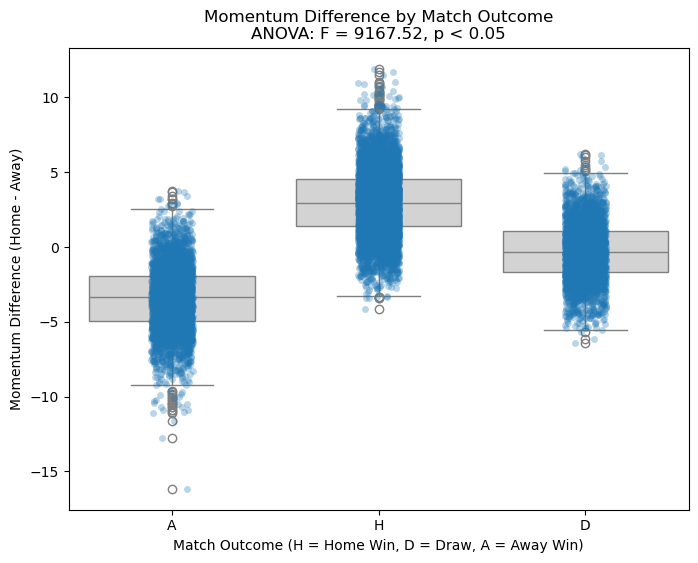

In [68]:
# Boxplot + stripplot to show momentum difference by match outcome
plt.figure(figsize=(8,6))

sns.boxplot(
    x="FullTimeResult",
    y="MomentumDiff",
    data=df,
    color="lightgray"
)

sns.stripplot(
    x="FullTimeResult",
    y="MomentumDiff",
    data=df,
    jitter=True,
    alpha=0.3
)

plt.title(
    f"Momentum Difference by Match Outcome\nANOVA: F = {f_stat:.2f}, p < 0.05"
)
plt.xlabel("Match Outcome (H = Home Win, D = Draw, A = Away Win)")
plt.ylabel("Momentum Difference (Home - Away)")

plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create smaller dataframe without missing values
anova_df = df[["FullTimeResult", "MomentumDiff"]].dropna()

tukey = pairwise_tukeyhsd(
    endog=anova_df["MomentumDiff"],
    groups=anova_df["FullTimeResult"],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
     A      D   3.1506   0.0 3.0222  3.279   True
     A      H   6.4346   0.0 6.3223 6.5469   True
     D      H    3.284   0.0 3.1673 3.4007   True
-------------------------------------------------
